In [2]:
from google.colab import files
uploaded = files.upload()

Saving fifa_world_cup_2026_player_performance.csv to fifa_world_cup_2026_player_performance.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("fifa_world_cup_2026_player_performance.csv")
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [5]:
print(df.shape)

df.info()

(54600, 75)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 

In [6]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

In [7]:
df.isnull().sum()

,0
player_id,0
player_name,0
age,0
nationality,0
team,0
...,...
total_goals_tournament,0
total_assists_tournament,0
total_minutes_tournament,0
player_of_match_awards,0


In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 54600
Columns: 75


In [9]:
top_players = df.sort_values(
    "player_rating",
    ascending=False
).head(10)

top_players[["player_name","team","player_rating"]]

,player_name,team,player_rating
43249,Mohamed Elneny,Egypt,9.4
38411,Memphis Zerrouki,Netherlands,9.2
29927,Anibal Sanchez,Panama,9.2
35232,Mohammed Otoo,Ghana,9.2
12958,Vinicius Nunes,Brazil,9.2
23356,Jackson Vukovic,Australia,9.1
14589,Sebastian Pellerano,Ecuador,8.9
52477,Mathew Behich,Australia,8.9
16701,Wilfred Iheanacho,Nigeria,8.9
9181,Sam James,Canada,8.9


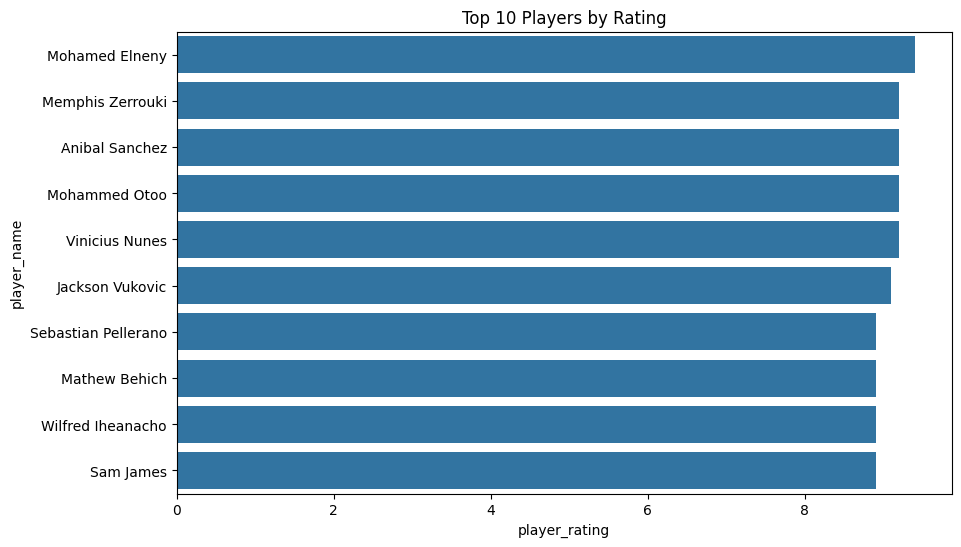

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_players,
    x="player_rating",
    y="player_name"
)

plt.title("Top 10 Players by Rating")
plt.show()

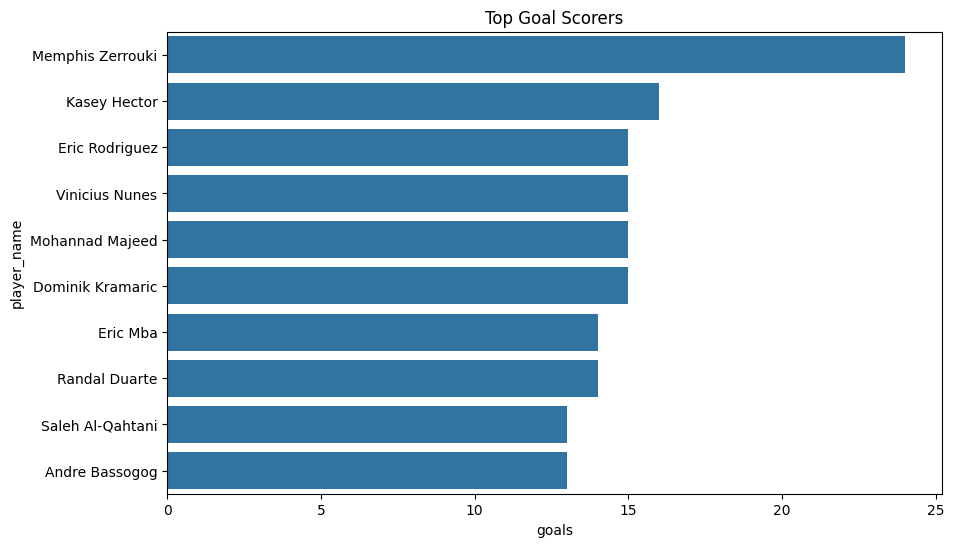

In [11]:
top_goals = df.groupby(
    ["player_name","team"]
)["goals"].sum().reset_index()

top_goals = top_goals.sort_values(
    "goals",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_goals,
    x="goals",
    y="player_name"
)

plt.title("Top Goal Scorers")
plt.show()

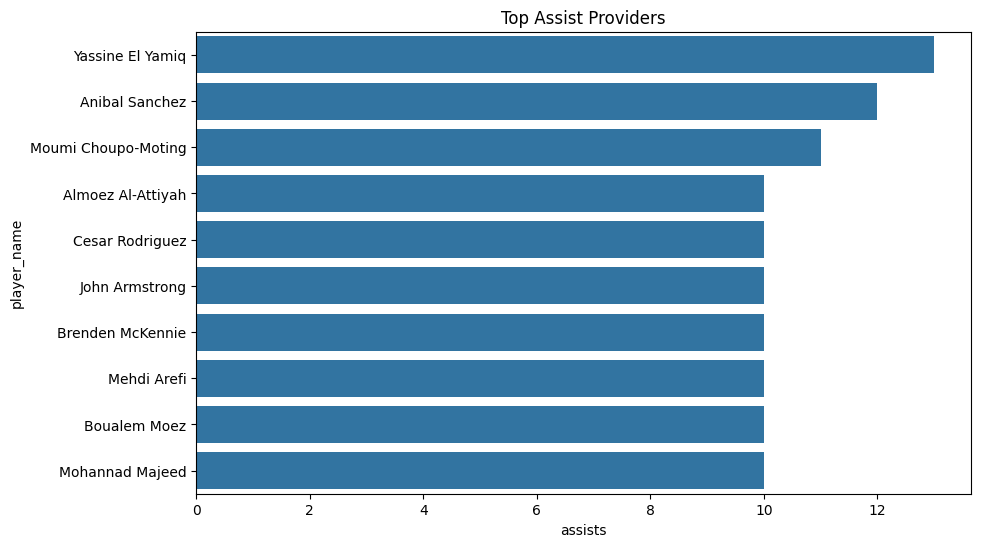

In [12]:
top_assists = df.groupby(
    ["player_name","team"]
)["assists"].sum().reset_index()

top_assists = top_assists.sort_values(
    "assists",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_assists,
    x="assists",
    y="player_name"
)

plt.title("Top Assist Providers")
plt.show()

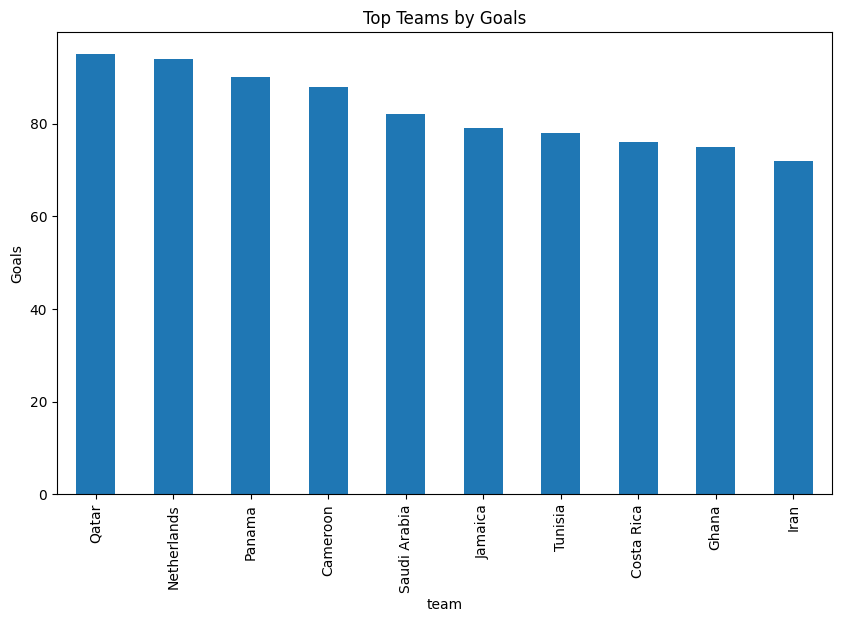

In [13]:
team_goals = df.groupby("team")["goals"].sum()

team_goals.sort_values(
    ascending=False
).head(10).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Top Teams by Goals")
plt.ylabel("Goals")
plt.show()

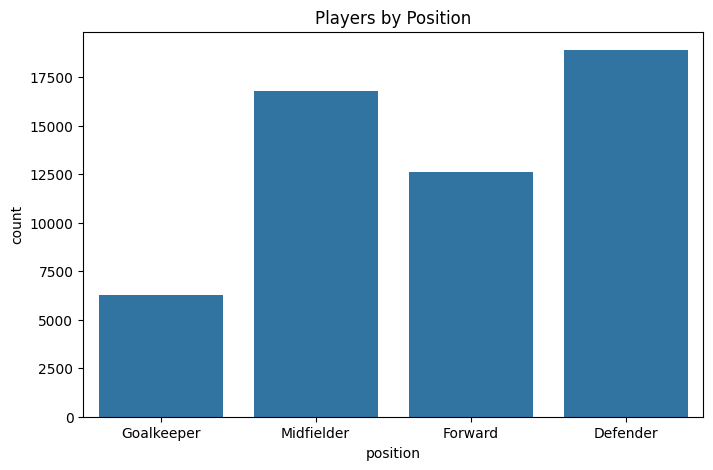

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="position"
)

plt.title("Players by Position")
plt.show()

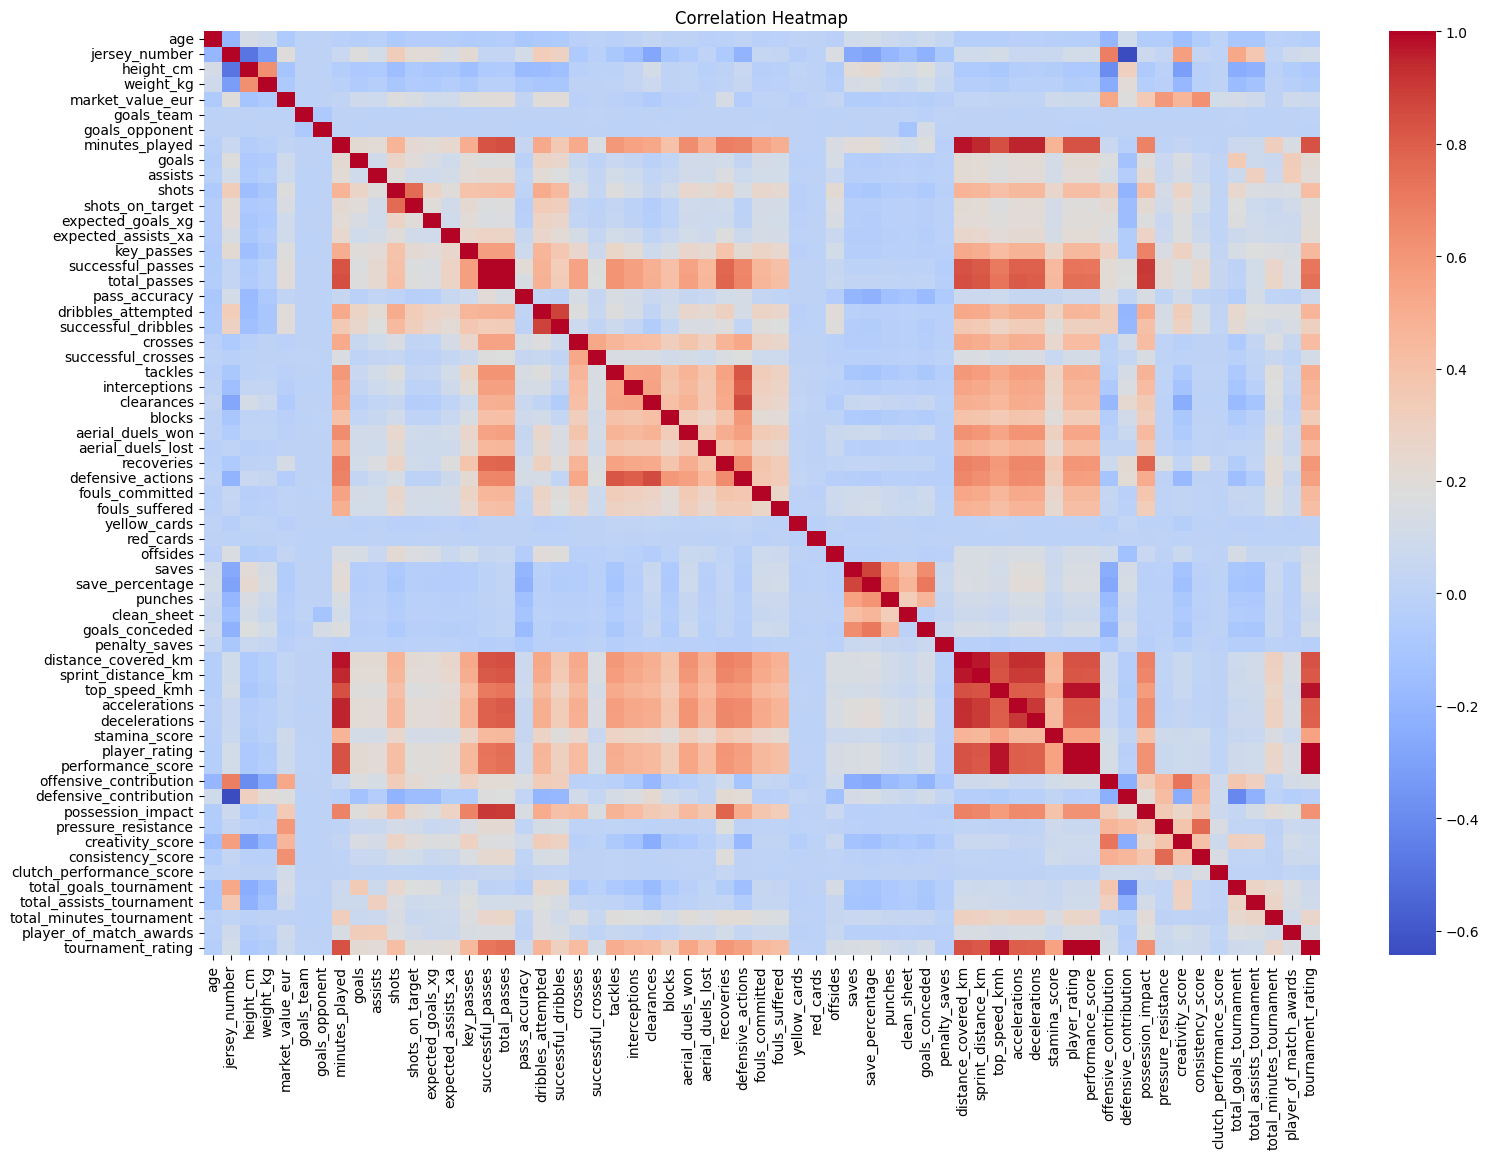

In [15]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(18,12))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [17]:
df["goal_efficiency"] = (
    df["goals"] /
    df["minutes_played"]
) * 90

In [18]:
df.sort_values(
    "goal_efficiency",
    ascending=False
)[["player_name","team","goal_efficiency"]].head(10)

,player_name,team,goal_efficiency
34048,Jose Gomez,Panama,18.000000
52792,Romelu Vanheusden,Belgium,12.857143
16054,Enner Zapata,Ecuador,10.000000
22007,Achraf El Yamiq,Morocco,10.000000
31939,Maximilian Bavoli,Austria,9.000000
28743,Diego Romo,Mexico,9.000000
42885,Ferran Morata,Spain,9.000000
31604,Mohammed Otoo,Ghana,9.000000
31030,Andre Antonio,Jamaica,9.000000
21697,Declan Saka,England,8.181818


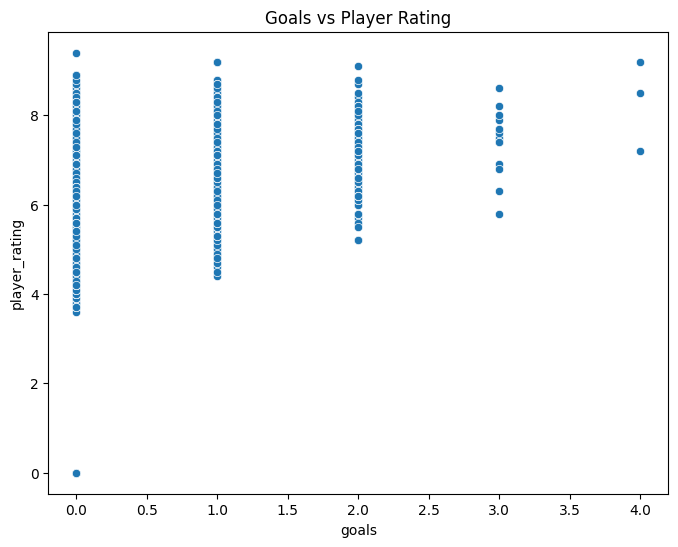

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="goals",
    y="player_rating"
)

plt.title("Goals vs Player Rating")
plt.show()

In [20]:
plt.savefig("top_players.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [21]:
plt.savefig("top_goal_scorers.png", bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [22]:
df.loc[df["player_rating"].idxmax(),
       ["player_name","team","player_rating"]]

,43249
player_name,Mohamed Elneny
team,Egypt
player_rating,9.4


In [23]:
df.groupby("player_name")["goals"].sum().sort_values(ascending=False).head(10)

,goals
player_name,
Memphis Zerrouki,24
Kasey Hector,16
Eric Rodriguez,15
Vinicius Nunes,15
Mohannad Majeed,15
Dominik Kramaric,15
Eric Mba,14
Randal Duarte,14
Saleh Al-Qahtani,13


In [24]:
df.groupby("player_name")["assists"].sum().sort_values(ascending=False).head(10)

,assists
player_name,
Yassine El Yamiq,13
Anibal Sanchez,12
Moumi Choupo-Moting,11
Almoez Al-Attiyah,10
Cesar Rodriguez,10
John Armstrong,10
Brenden McKennie,10
Mehdi Arefi,10
Boualem Moez,10


In [25]:
df.groupby("team")["goals"].sum().sort_values(ascending=False).head(10)

,goals
team,
Qatar,95
Netherlands,94
Panama,90
Cameroon,88
Saudi Arabia,82
Jamaica,79
Tunisia,78
Costa Rica,76
Ghana,75
